In [1]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [2]:
wine=load_wine()

In [3]:
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine.data, wine.target, test_size=0.5, random_state=1)

In [4]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

In [5]:
bc1 = BaggingClassifier(n_estimators=5, oob_score=True, random_state=10)
bc1.fit(wine_X_train, wine_y_train)

C:\Users\masha\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:917: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
C:\Users\masha\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:923: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


,estimator,None
,n_estimators,5
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,None
,random_state,10
,verbose,0


In [6]:
bc1.estimators_samples_

[array([37,  9, 49, 52, 14, 10, 26, 74, 24, 10, 63, 51, 50, 44, 67, 34, 24,
        43, 59, 21, 58, 58, 46, 75, 27, 74, 19, 37, 45, 59, 54,  4, 44, 14,
        69, 28, 75, 74, 23, 39, 60, 64, 43,  0, 50, 73, 22, 78, 43, 42, 77,
        28, 50,  4, 14, 56, 42, 68, 76, 43, 39, 68, 63, 43, 11, 84, 80, 48,
        31, 56, 54, 71, 50, 82, 10,  8, 77,  4, 79, 62, 44, 60, 74, 25, 67,
         9, 69, 25, 88], dtype=int32),
 array([87, 46,  1, 44,  8, 87, 21, 61, 68, 87, 55, 31, 34, 17, 58, 34, 38,
        79, 21, 80, 88, 38, 70, 22, 88, 39, 52, 24, 19, 44, 19, 30, 15, 49,
        50, 39, 52, 41,  2, 14, 47, 33, 18, 13, 10, 13, 62, 24, 15, 63, 57,
        17, 48, 62, 52, 23, 52,  0, 87, 16, 67, 50, 59, 82, 43, 55,  7, 82,
         4, 51, 35, 78, 52, 35, 63, 81, 58, 67, 20, 81, 54, 88, 49, 49, 41,
        16, 86, 13, 67], dtype=int32),
 array([25, 54,  3, 76, 41, 54, 55, 77, 38, 13, 40, 18, 72, 51, 50, 29, 42,
        61, 54, 45, 21, 42, 82,  7, 28, 72, 71, 51, 81, 88, 72, 71, 24, 39,
         1

In [7]:
# Сконвертируем эти данные в двоичную матрицу, 
# 1 соответствует элементам, попавшим в обучающую выборку
bin_array = np.zeros((5, wine_X_train.shape[0]))
for i in range(5):
    for j in bc1.estimators_samples_[i]:
        bin_array[i][j] = 1
bin_array

array([[1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0.,
        0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1.,
        0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0.,
        1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 1., 1.,
        1., 0., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
        1., 0., 1., 0., 1., 0., 0., 0., 1.],
       [1., 1., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1.,
        0., 1., 1., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1.,
        1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1.,
        0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
        1., 1., 1., 0., 0., 0., 1., 1., 1.],
       [1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0.,
        0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0.,
        1., 0., 1., 0., 1., 1., 1., 1., 1., 1.

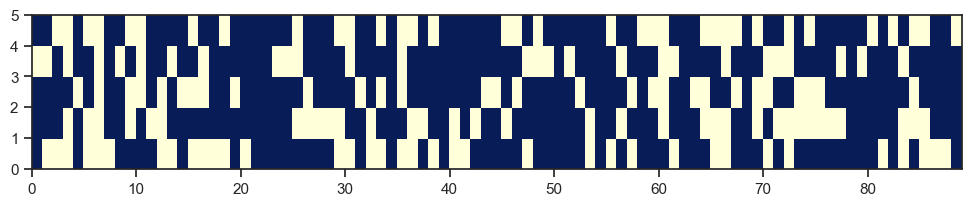

In [8]:
# И визуализируем (синим цветом показаны данные, которые попали в обучающую выборку)
fig, ax = plt.subplots(figsize=(12,2))
ax.pcolor(bin_array, cmap='YlGnBu')
plt.show()

In [9]:
# Оценим Out-of-bag error, теоретическое значение 37%
for i in range(5):
    cur_data = bin_array[i]
    len_cur_data = len(cur_data)
    sum_cur_data = sum(cur_data)
    (len(bin_array[0]) - sum(bin_array[0])) / len(bin_array[0])
    oob_i = (len_cur_data - sum_cur_data) / len_cur_data
    print('Для модели № {} размер OOB составляет {}%'.format(i+1, round(oob_i, 4)*100.0))

Для модели № 1 размер OOB составляет 40.45%
Для модели № 2 размер OOB составляет 38.2%
Для модели № 3 размер OOB составляет 32.58%
Для модели № 4 размер OOB составляет 30.34%
Для модели № 5 размер OOB составляет 38.2%


In [10]:
# Out-of-bag error, возвращаемый классификатором
# Для классификации используется метрика accuracy
bc1.oob_score_, 1-bc1.oob_score_

(0.8314606741573034, 0.1685393258426966)

In [11]:
# Параметр oob_decision_function_ возвращает вероятности 
# принадлежности объекта к классам на основе oob
# В данном примере три класса, 
# значения nan могут возвращаться в случае маленькой выборки
bc1.oob_decision_function_[55:70]

array([[0.  , 0.  , 1.  ],
       [1.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [ nan,  nan,  nan],
       [0.  , 1.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  ],
       [0.25, 0.  , 0.75],
       [0.  , 1.  , 0.  ],
       [ nan,  nan,  nan],
       [0.  , 1.  , 0.  ]])

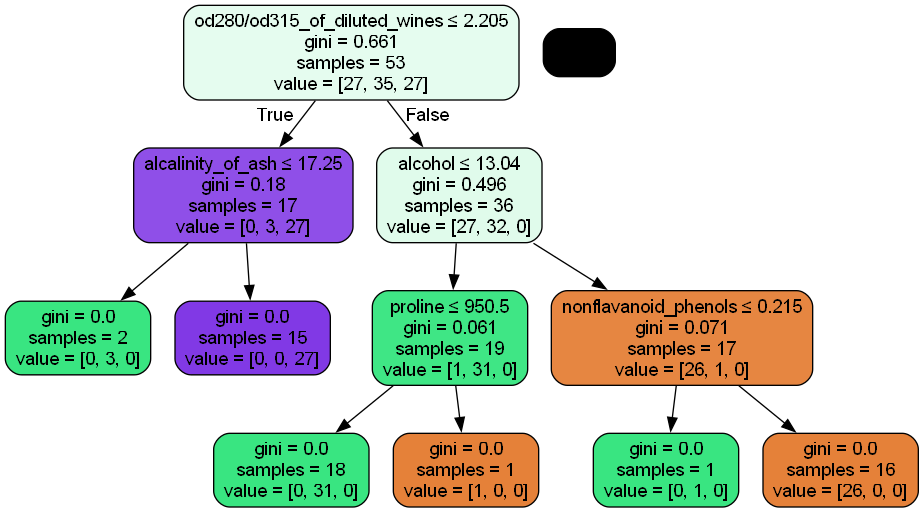

In [13]:
from IPython.display import Image
from io import StringIO
import graphviz
import pydotplus
from sklearn.tree import export_graphviz  

# Визуализация дерева
def get_png_tree(tree_model_param, feature_names_param):
    dot_data = StringIO()
    export_graphviz(tree_model_param, out_file=dot_data, 
                    feature_names=feature_names_param,
                    filled=True, rounded=True, special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return graph.create_png()

# Визуализация обученных решающих деревьев
Image(get_png_tree(bc1.estimators_[0], wine.feature_names), width='80%')

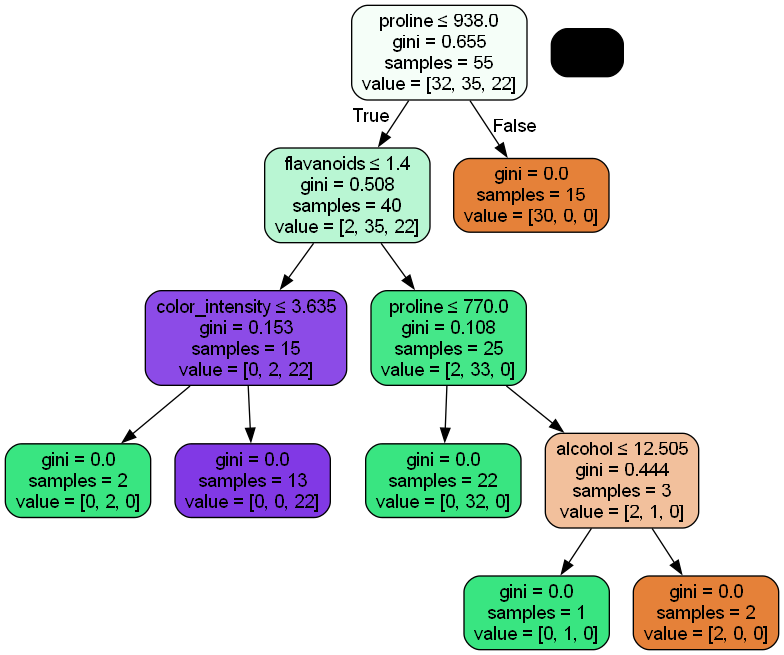

In [14]:
Image(get_png_tree(bc1.estimators_[1], wine.feature_names), width='80%')

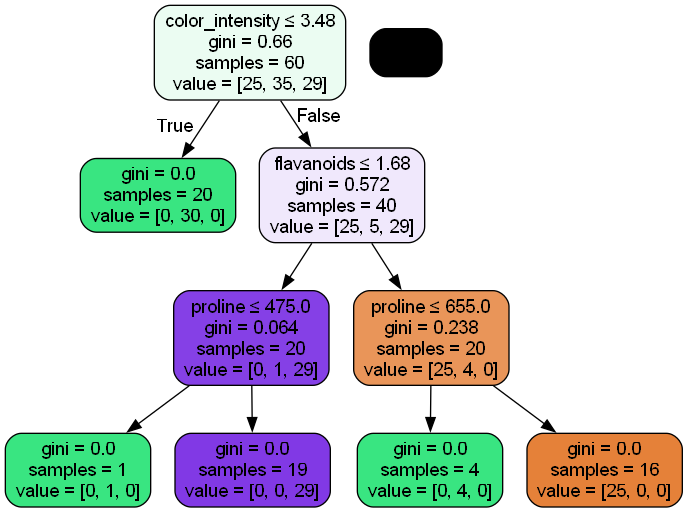

In [17]:
Image(get_png_tree(bc1.estimators_[2], wine.feature_names), width='80%')

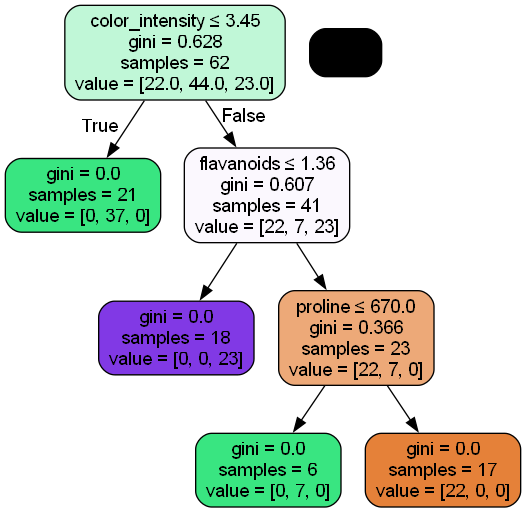

In [18]:
Image(get_png_tree(bc1.estimators_[3], wine.feature_names), width='80%')

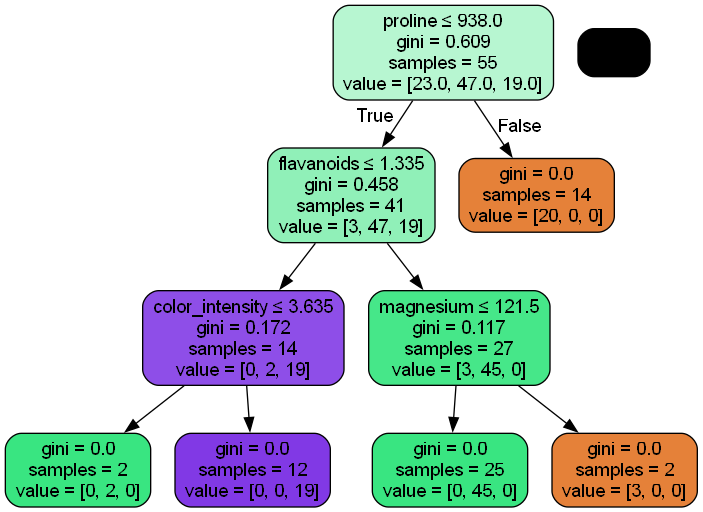

In [19]:
Image(get_png_tree(bc1.estimators_[4], wine.feature_names), width='80%')

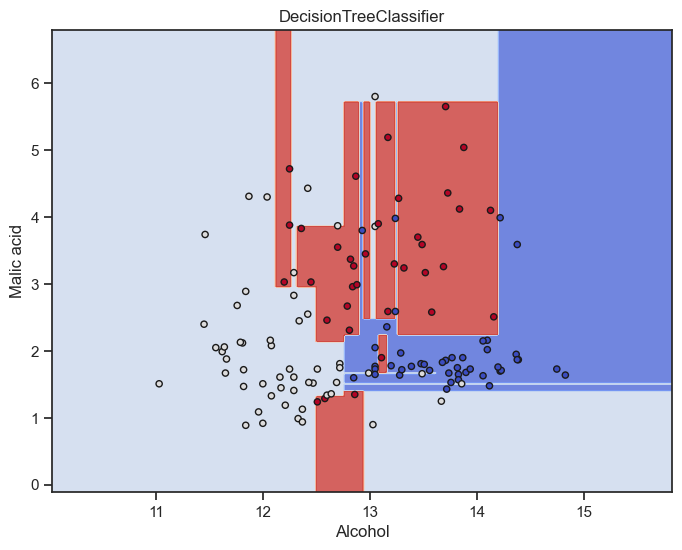

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# Загружаем данные
X = wine.data[:, :2]  
y = wine.target

def make_meshgrid(x, y, h=.02):
    """Create a mesh of points to plot in"""
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier."""
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])  # Исправлено: np.c_ вместо np.cl_
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

def plot_cl(clf):
    clf.fit(wine_X_train, wine_y_train)
    fig, ax = plt.subplots(figsize=(8, 6))
    X0, X1 = wine_X_train[:, 0], wine_X_train[:, 1]
    xx, yy = make_meshgrid(X0, X1)
    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)  # Исправлено: coolwarm
    ax.scatter(X0, X1, c=wine_y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')  # Исправлено: wine_y_train
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Alcohol')  # Первый признак
    ax.set_ylabel('Malic acid')  # Второй признак
    ax.set_title(str(clf.__class__.__name__))  # Исправлено: __class__.__name__
    plt.show()

# Запускаем
plot_cl(DecisionTreeClassifier(random_state=1))

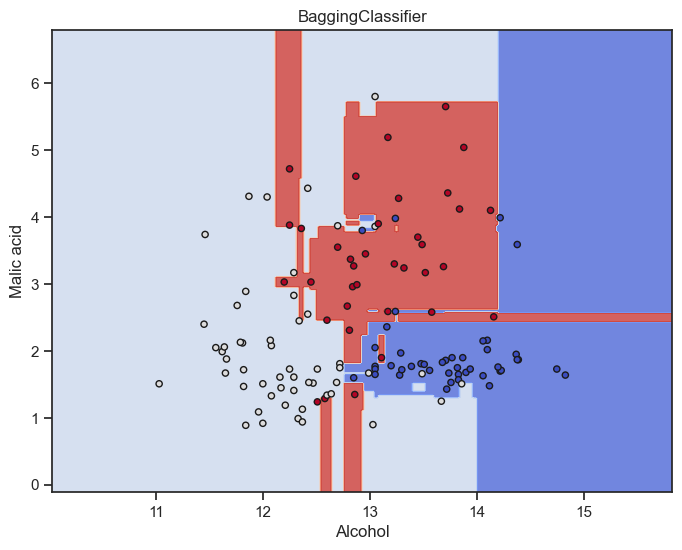

In [29]:
plot_cl(BaggingClassifier(DecisionTreeClassifier(random_state=1), n_estimators=5))

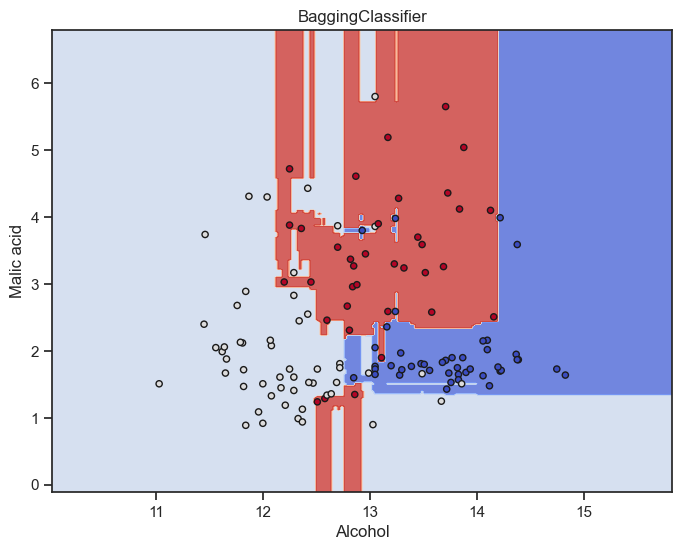

In [30]:
plot_cl(BaggingClassifier(DecisionTreeClassifier(random_state=1), n_estimators=100))

In [31]:
from sklearn.ensemble import AdaBoostClassifier
# Обучим классификатор на 5 деревьях
ab1 = AdaBoostClassifier(n_estimators=5, algorithm='SAMME', random_state=10)
ab1.fit(wine_X_train, wine_y_train)

C:\Users\masha\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


,estimator,None
,n_estimators,5
,learning_rate,1.0
,algorithm,'SAMME'
,random_state,10


In [34]:
ab1.estimator_weights_

array([1.43175674, 1.5383951 , 0.96733629, 0.80652856, 1.18558512])

In [35]:
df1 = ab1.decision_function(wine_X_train)
df1.shape

(133, 3)

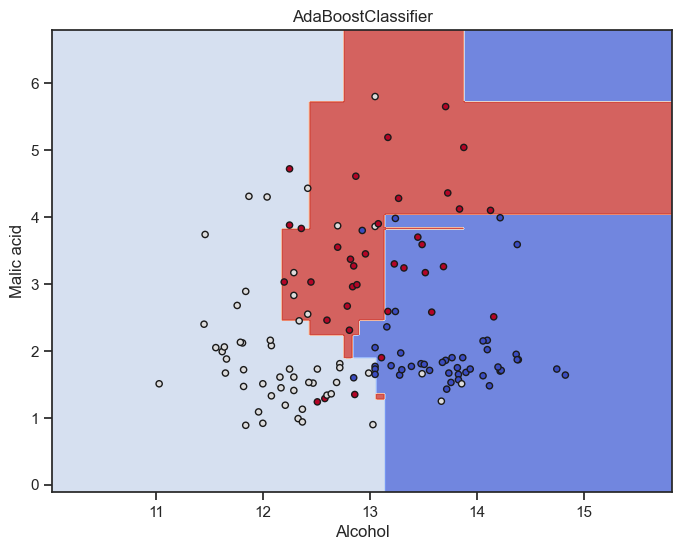

In [36]:
# Результаты классификации
plot_cl(AdaBoostClassifier(random_state=1))

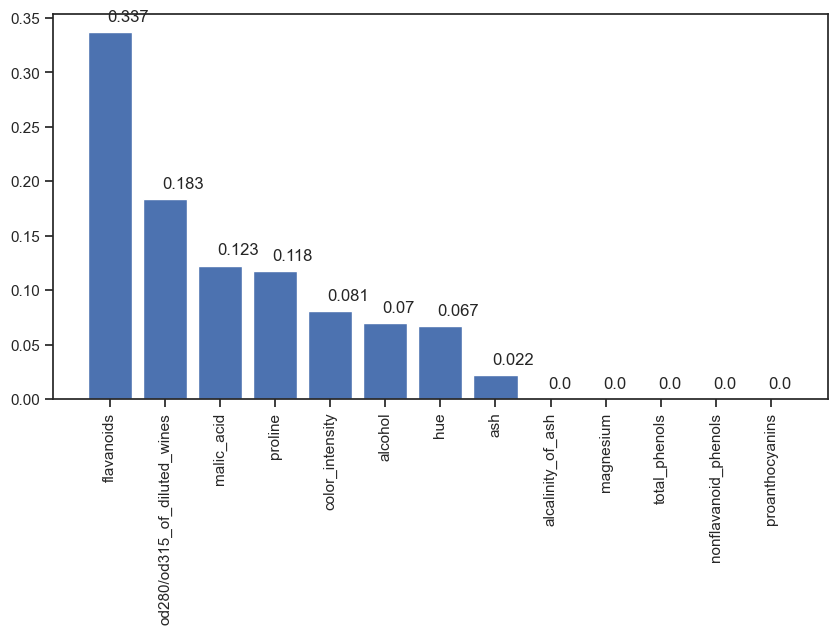

In [38]:
from operator import itemgetter

def draw_feature_importances(tree_model, X_dataset, figsize=(10,5)):
    """
    Вывод важности признаков в виде графика
    """
    # Сортировка значений важности признаков по убыванию
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse = True)
    # Названия признаков
    labels = [x for x,_ in sorted_list]
    # Важности признаков
    data = [x for _,x in sorted_list]
    # Вывод графика
    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    plt.bar(ind, data)
    plt.xticks(ind, labels, rotation='vertical')
    # Вывод значений
    for a,b in zip(ind, data):
        plt.text(a-0.05, b+0.01, str(round(b,3)))
    plt.show()
    return labels, data
# Важность признаков
wine_x_ds = pd.DataFrame(data=wine['data'], columns=wine['feature_names'])
ab2 = AdaBoostClassifier(random_state=1)
ab2.fit(wine_x_ds, wine.target)
_,_ = draw_feature_importances(ab2, wine_x_ds)

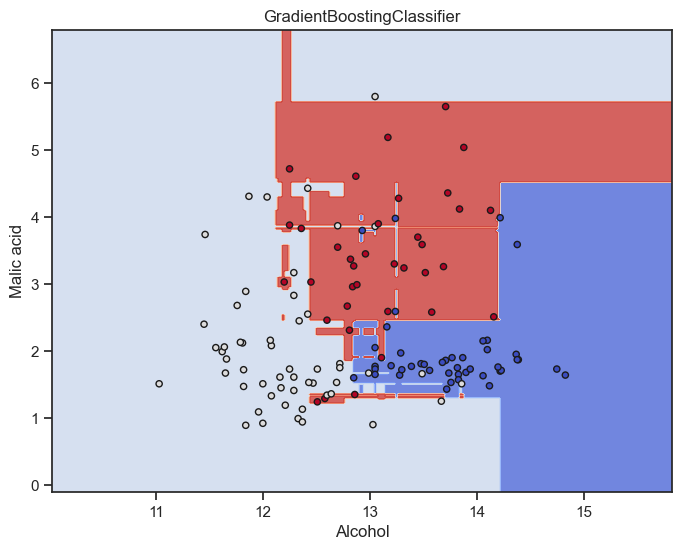

In [39]:
plot_cl(GradientBoostingClassifier(random_state=1))

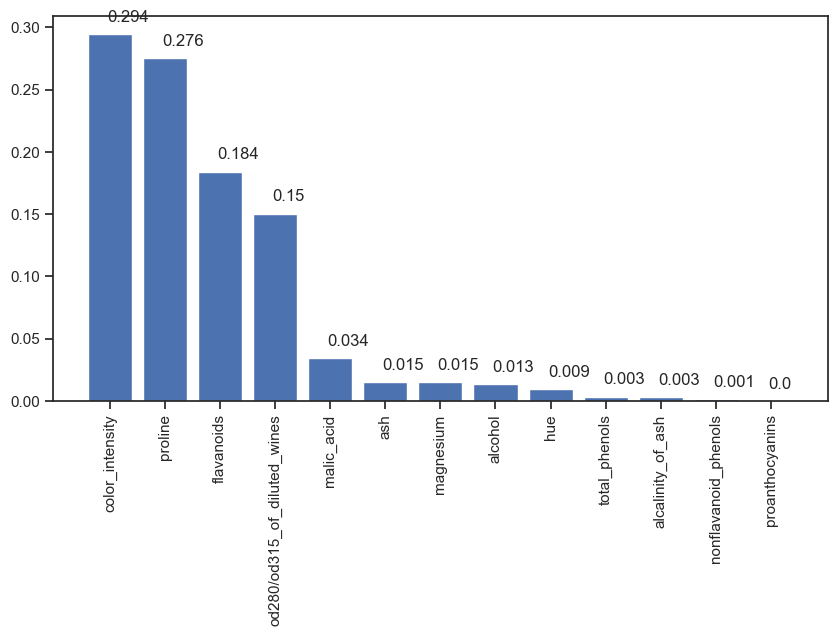

In [40]:
# Важность признаков
wine_gb_cl = GradientBoostingClassifier(random_state=1)
wine_gb_cl.fit(wine_x_ds, wine.target)
_,_ = draw_feature_importances(wine_gb_cl, wine_x_ds)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Используем ВСЕ признаки wine.data (13 признаков)
X_full = wine.data
y_full = wine.target

# Разделяем на обучающую и тестовую выборки
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_full
)

print(f"Обучающая выборка: {X_train_full.shape}")  # (124, 13)
print(f"Тестовая выборка: {X_test_full.shape}")    # (54, 13)

# Переобучаем модели на ПОЛНЫХ данных (13 признаков)
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

print("\nПереобучение моделей на 13 признаках...")

bc1_full = BaggingClassifier(n_estimators=5, random_state=10)
bc1_full.fit(X_train_full, y_train_full)

ab1_full = AdaBoostClassifier(n_estimators=5, algorithm='SAMME', random_state=10)
ab1_full.fit(X_train_full, y_train_full)

ab2_full = AdaBoostClassifier(random_state=1)
ab2_full.fit(X_train_full, y_train_full)

gb_full = GradientBoostingClassifier(random_state=1)
gb_full.fit(X_train_full, y_train_full)

# Оцениваем все модели
models_full = {
    'Bagging (n=5)': bc1_full,
    'AdaBoost (n=5)': ab1_full,
    'AdaBoost (n=50)': ab2_full,
    'Gradient Boosting': gb_full,
}

results = []
for name, model in models_full.items():
    y_pred = model.predict(X_test_full)
    results.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test_full, y_pred),
        'Precision': precision_score(y_test_full, y_pred, average='weighted'),
        'Recall': recall_score(y_test_full, y_pred, average='weighted'),
        'F1-score': f1_score(y_test_full, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

print("\n" + "="*70)
print("СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ")
print("="*70)
print(results_df.to_string(index=False))

print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {results_df.iloc[0]['Модель']}")
print(f"   Точность (Accuracy): {results_df.iloc[0]['Accuracy']:.4f}")

Обучающая выборка: (124, 13)
Тестовая выборка: (54, 13)

Переобучение моделей на 13 признаках...


C:\Users\masha\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(



СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ
           Модель  Accuracy  Precision   Recall  F1-score
  AdaBoost (n=50)  0.981481   0.982639 0.981481  0.981554
Gradient Boosting  0.962963   0.966184 0.962963  0.962715
    Bagging (n=5)  0.925926   0.925994 0.925926  0.925431
   AdaBoost (n=5)  0.907407   0.908824 0.907407  0.906642

🏆 ЛУЧШАЯ МОДЕЛЬ: AdaBoost (n=50)
   Точность (Accuracy): 0.9815
